## Imports and SEED

In [1]:
import os
import random
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Path

In [2]:
from dotenv import load_dotenv

load_dotenv()

DATA_DIR = Path(os.environ["DATA_DIR"])
WEIGHTS_DIR = Path(os.environ["WEIGHTS_DIR"])

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


## Params


In [3]:
MODEL_NAME = "beit_base_patch16_224.in22k_ft_in22k"  # timm model id (used for config, not download)
IMG_SIZE = 224
NUM_CLASSES = 15  

# Fine-tuning strategy: unfreeze last N transformer blocks + head
NUM_UNFROZEN_BLOCKS = 4

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_WORKERS = 8

NUM_EPOCHS = 20
LR_HEAD = 1e-3        # higher LR for newly initialized head
LR_BACKBONE = 1e-5    # lower LR for unfrozen backbone blocks
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 2

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100 80GB PCIe
VRAM: 85.0 GB


In [5]:
print(f"\nData dir exists: {DATA_DIR.exists()}")
print(f"Weights dir exists: {WEIGHTS_DIR.exists()}")



Data dir exists: True
Weights dir exists: True


## Data Exploration and Visualization

In [9]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
from PIL import Image

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]

print(f"Found {len(class_names)} classes:")
for c in class_names:
    print(" -", c)

if len(class_names) != NUM_CLASSES:
    print(f"\n WARNING: NUM_CLASSES in Cell 1 is {NUM_CLASSES}, "
          f"but found {len(class_names)} folders. Update Cell 1's NUM_CLASSES.")
else:
    print(f"\n NUM_CLASSES matches ({NUM_CLASSES})")

Found 15 classes:
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot
 - Tomato_Spider_mites_Two_spotted_spider_mite
 - Tomato__Target_Spot
 - Tomato__Tomato_YellowLeaf__Curl_Virus
 - Tomato__Tomato_mosaic_virus
 - Tomato_healthy

 NUM_CLASSES matches (15)


In [10]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

class_to_files = {}
for d in class_dirs:
    files = [f for f in d.iterdir() if f.suffix in VALID_EXTS]
    class_to_files[d.name] = files

counts = {c: len(files) for c, files in class_to_files.items()}
total_images = sum(counts.values())

print(f"\nTotal images: {total_images}")


Total images: 20638


In [11]:
print("\nPer-class counts:")

for c, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {c:50s} {n:5d}")



Per-class counts:
  Tomato__Tomato_YellowLeaf__Curl_Virus               3208
  Tomato_Bacterial_spot                               2127
  Tomato_Late_blight                                  1909
  Tomato_Septoria_leaf_spot                           1771
  Tomato_Spider_mites_Two_spotted_spider_mite         1676
  Tomato_healthy                                      1591
  Pepper__bell___healthy                              1478
  Tomato__Target_Spot                                 1404
  Potato___Early_blight                               1000
  Potato___Late_blight                                1000
  Tomato_Early_blight                                 1000
  Pepper__bell___Bacterial_spot                        997
  Tomato_Leaf_Mold                                     952
  Tomato__Tomato_mosaic_virus                          373
  Potato___healthy                                     152


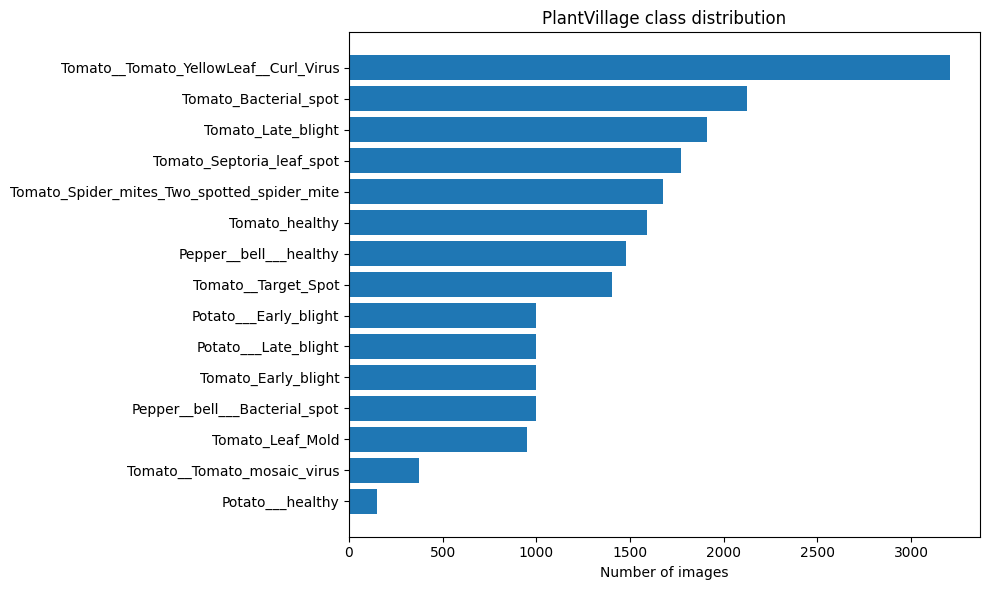

In [12]:
plt.figure(figsize=(10, 6))
sorted_items = sorted(counts.items(), key=lambda x: -x[1])
plt.barh([c for c, _ in sorted_items], [n for _, n in sorted_items])
plt.xlabel("Number of images")
plt.title("PlantVillage class distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

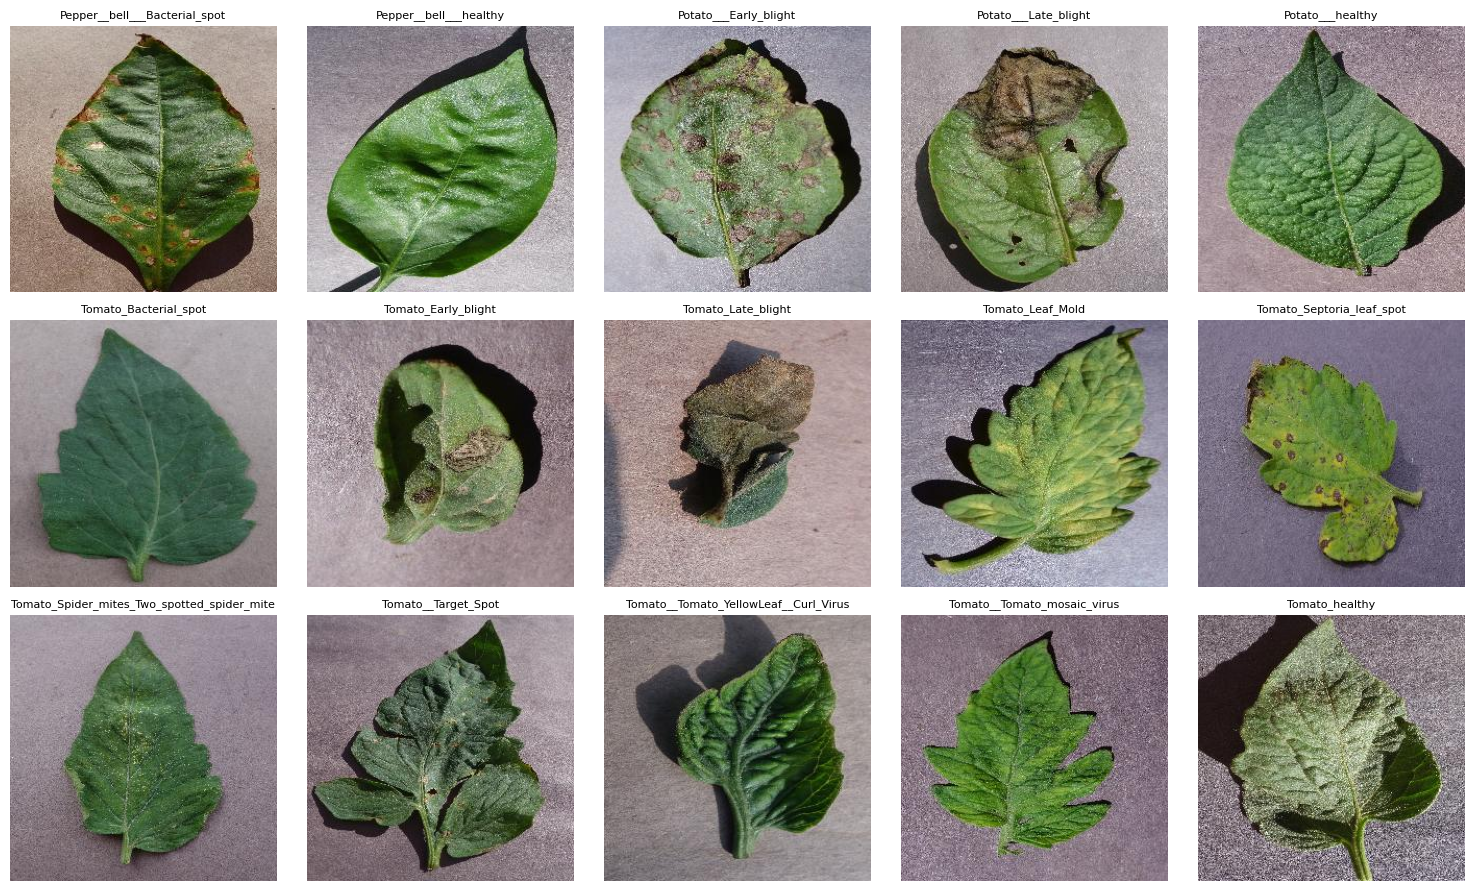

In [13]:
n_show = min(15, len(class_names))
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, c in enumerate(class_names[:n_show]):
    files = class_to_files[c]
    if not files:
        continue
    img_path = random.choice(files)
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(c, fontsize=8)
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()